# EDA

## Imports

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Basic information

In [115]:
df = pd.read_csv('Datos riego.csv', header=None, names=['temperatura', 'humedad', 'luz', 'humedad_suelo'])

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (804, 4)

Data Types:
temperatura      float64
humedad          float64
luz                int64
humedad_suelo      int64
dtype: object

Basic Statistics:
       temperatura  humedad          luz  humedad_suelo
count   804.000000    804.0   804.000000     804.000000
mean     12.979614      0.0  2024.269900    1045.082090
std       0.126438      0.0   325.326988      32.455594
min      12.760000      0.0  1643.000000     826.000000
25%      12.940000      0.0  1904.000000    1045.000000
50%      12.940000      0.0  1936.000000    1052.000000
75%      12.980000      0.0  2037.500000    1058.000000
max      13.410000      0.0  4091.000000    1070.000000


In [116]:
print("\nMissing Values:")
print(df.isnull().sum())
print("\nNull Values Count:", df.isnull().sum().sum())


Missing Values:
temperatura      0
humedad          0
luz              0
humedad_suelo    0
dtype: int64

Null Values Count: 0


## Correlation Matrix

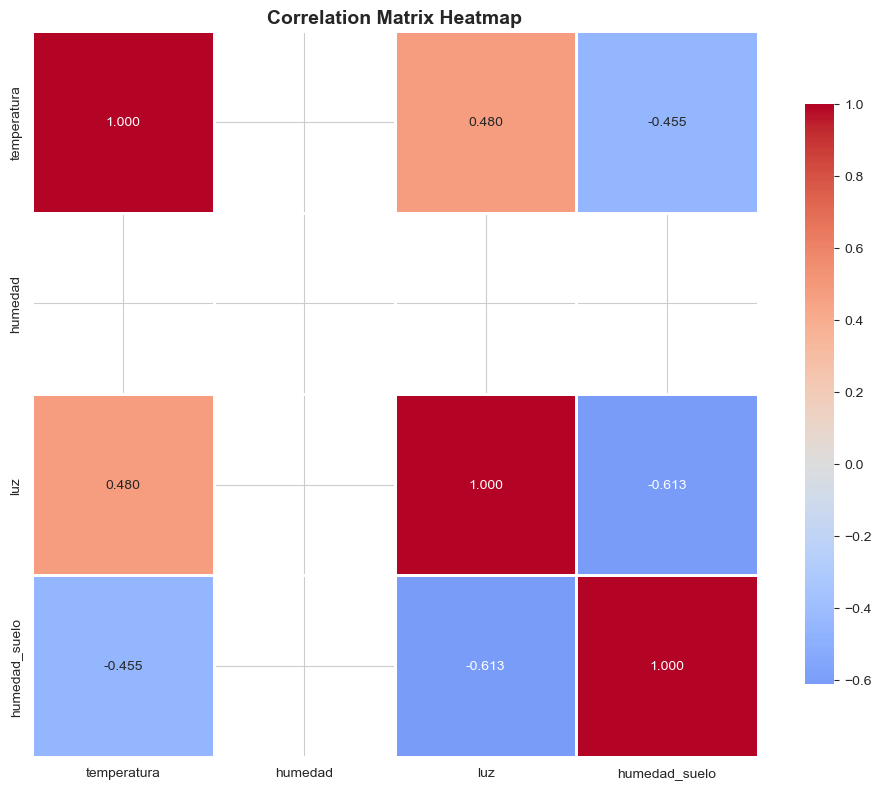

In [117]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f', cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [118]:
print("Correlation Matrix Analysis:\n")
print(correlation_matrix)
print("\n" + "="*60)
print("Correlación por pares (excluyendo auto-correlación):")
print("="*60)

# Extraer correlaciones significativas
correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        col_i = correlation_matrix.columns[i]
        col_j = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        correlations.append({
            'Variable 1': col_i,
            'Variable 2': col_j,
            'Correlación': corr_value,
            'Fuerza': 'Muy Fuerte' if abs(corr_value) > 0.8 else 'Fuerte' if abs(corr_value) > 0.6 else 'Moderada' if abs(corr_value) > 0.4 else 'Nula'
        })

corr_df = pd.DataFrame(correlations).sort_values('Correlación', key=abs, ascending=False)
print(corr_df.to_string(index=False))

print("\n" + "="*60)
print("Interpretación:")
print("="*60)
strong_corr = corr_df[abs(corr_df['Correlación']) > 0.6]
if len(strong_corr) == 0:
    print("✓ No hay correlaciones fuertes (>0.6) entre variables")
    print("✓ Las variables son relativamente independientes")
    print("✓ Esto sugiere que cada sensor captura información única del sistema")
else:
    print("Variables con correlación fuerte (>0.6):")
    for idx, row in strong_corr.iterrows():
        print(f"  - {row['Variable 1']} vs {row['Variable 2']}: {row['Correlación']:.3f}")

Correlation Matrix Analysis:

               temperatura  humedad       luz  humedad_suelo
temperatura       1.000000      NaN  0.480396      -0.454741
humedad                NaN      NaN       NaN            NaN
luz               0.480396      NaN  1.000000      -0.612653
humedad_suelo    -0.454741      NaN -0.612653       1.000000

Correlación por pares (excluyendo auto-correlación):
 Variable 1    Variable 2  Correlación   Fuerza
        luz humedad_suelo    -0.612653   Fuerte
temperatura           luz     0.480396 Moderada
temperatura humedad_suelo    -0.454741 Moderada
temperatura       humedad          NaN     Nula
    humedad           luz          NaN     Nula
    humedad humedad_suelo          NaN     Nula

Interpretación:
Variables con correlación fuerte (>0.6):
  - luz vs humedad_suelo: -0.613


## PCA

PCA Analysis:
Explained Variance Ratio: [0.67837808 0.19293225 0.12868967 0.        ]
Cumulative Explained Variance: [0.67837808 0.87131033 1.         1.        ]


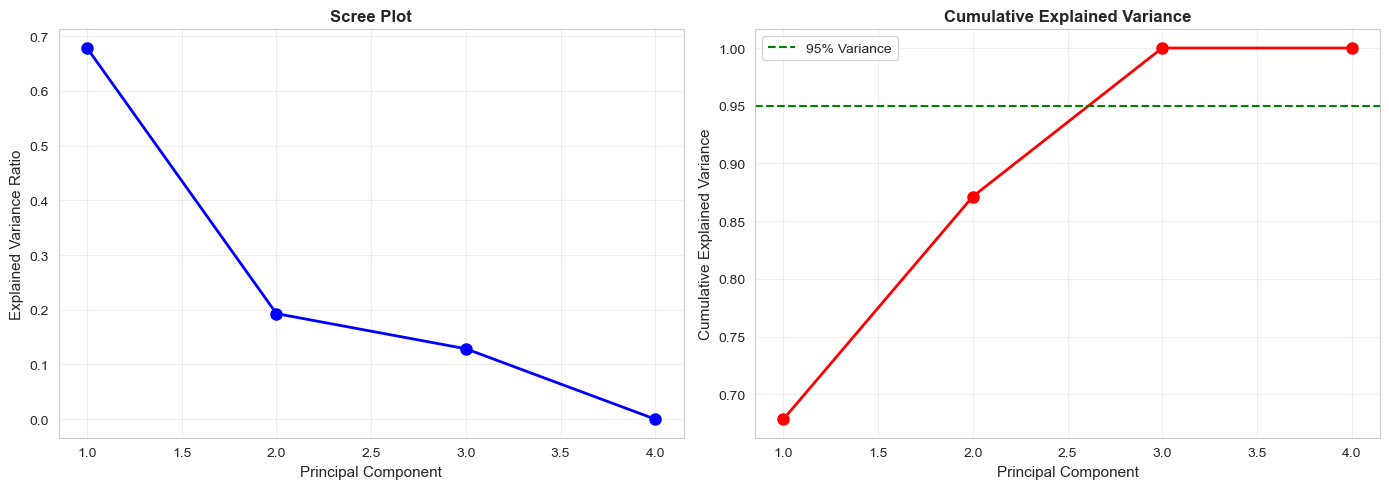

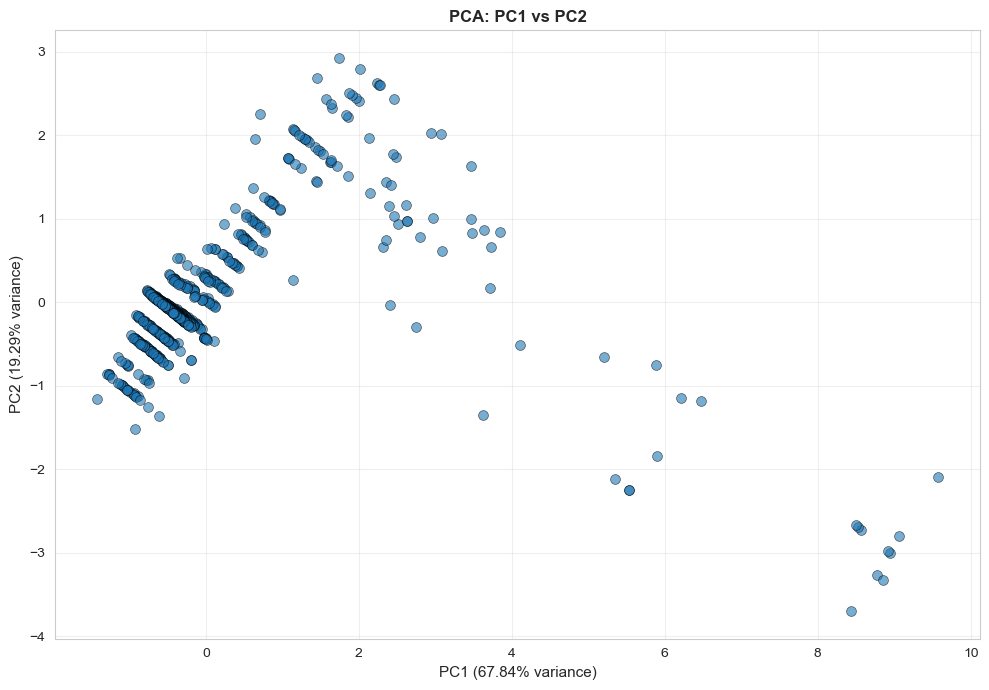

In [119]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
imputed_data = imputer.fit_transform(df[numeric_cols])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

pca = PCA()
pca_data = pca.fit_transform(scaled_data)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("PCA Analysis:")
print(f"Explained Variance Ratio: {explained_variance_ratio}")
print(f"Cumulative Explained Variance: {cumulative_variance}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=11)
axes[0].set_title('Scree Plot', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
axes[1].set_xlabel('Principal Component', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pca_df = pd.DataFrame(data=pca_data[:, :2], columns=['PC1', 'PC2'])
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.xlabel(f'PC1 ({explained_variance_ratio[0]:.2%} variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained_variance_ratio[1]:.2%} variance)', fontsize=11)
plt.title('PCA: PC1 vs PC2', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

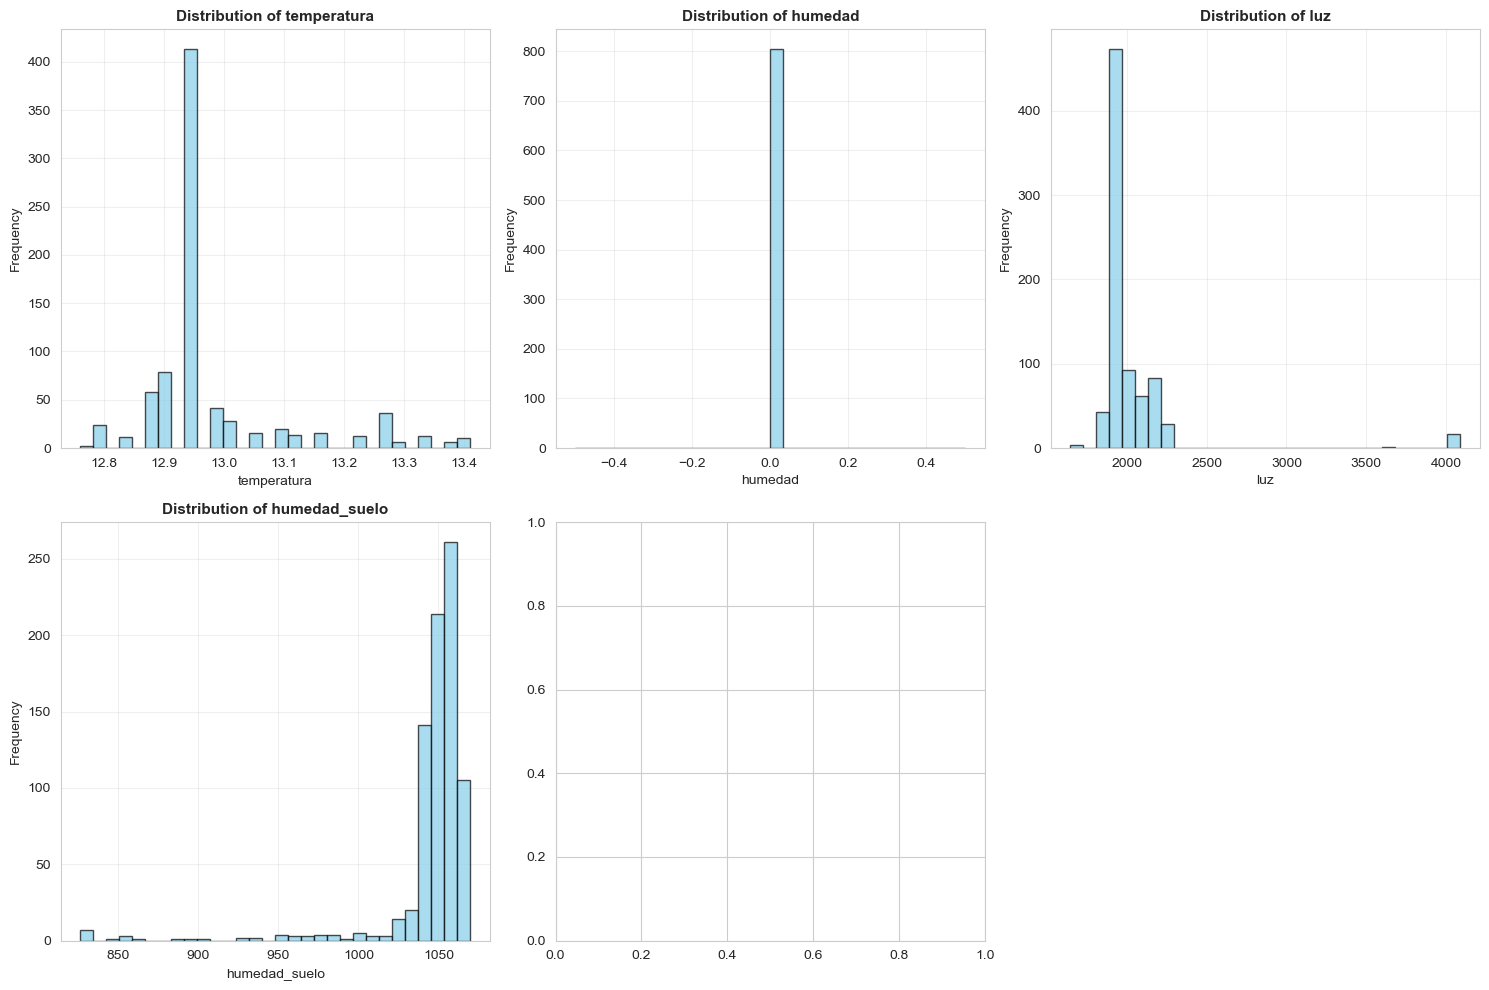

In [120]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

if len(numeric_cols) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

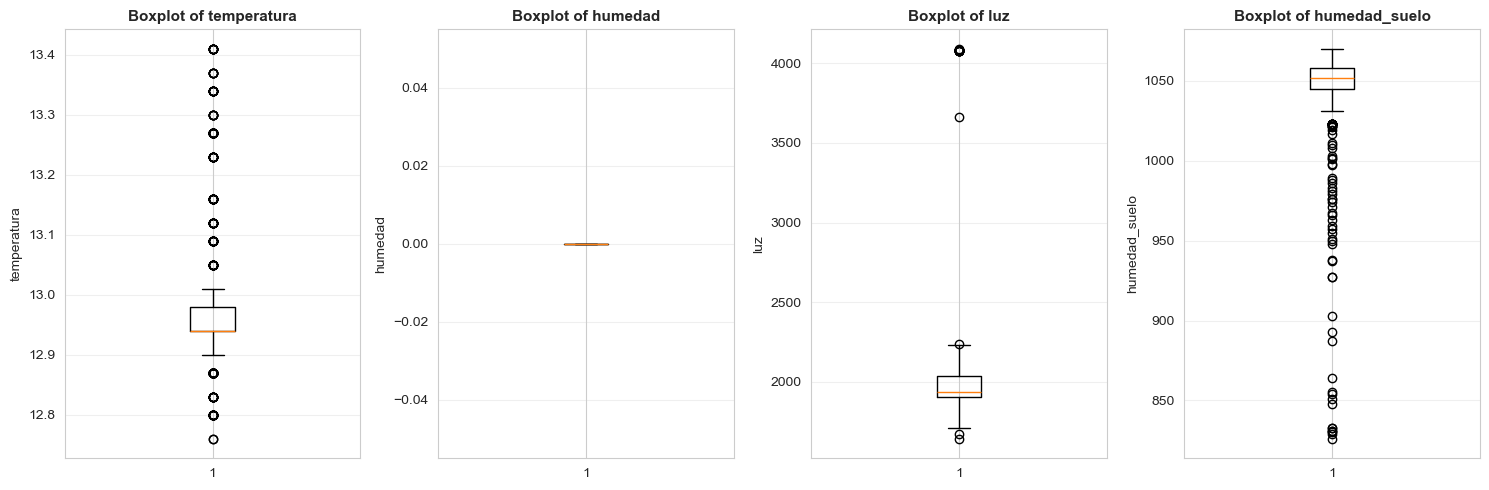

In [121]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))

if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].set_title(f'Boxplot of {col}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [122]:
print("\nAnálisis de Outliers:")
print("="*60)
total_outliers = 0
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    total_outliers += len(outliers)
    
    if len(outliers) > 0:
        pct = (len(outliers) / len(df)) * 100
        print(f"\n{col}:  {len(outliers)} outliers ({pct:.1f}%)")
    else:
        print(f"\n{col}:  Sin outliers")

print("\n" + "="*60)
print(f"Total outliers detectados: {total_outliers} de {len(df)} registros ({(total_outliers/len(df)*100):.1f}%)")


Análisis de Outliers:

temperatura:  243 outliers (30.2%)

humedad:  Sin outliers

luz:  21 outliers (2.6%)

humedad_suelo:  63 outliers (7.8%)

Total outliers detectados: 327 de 804 registros (40.7%)


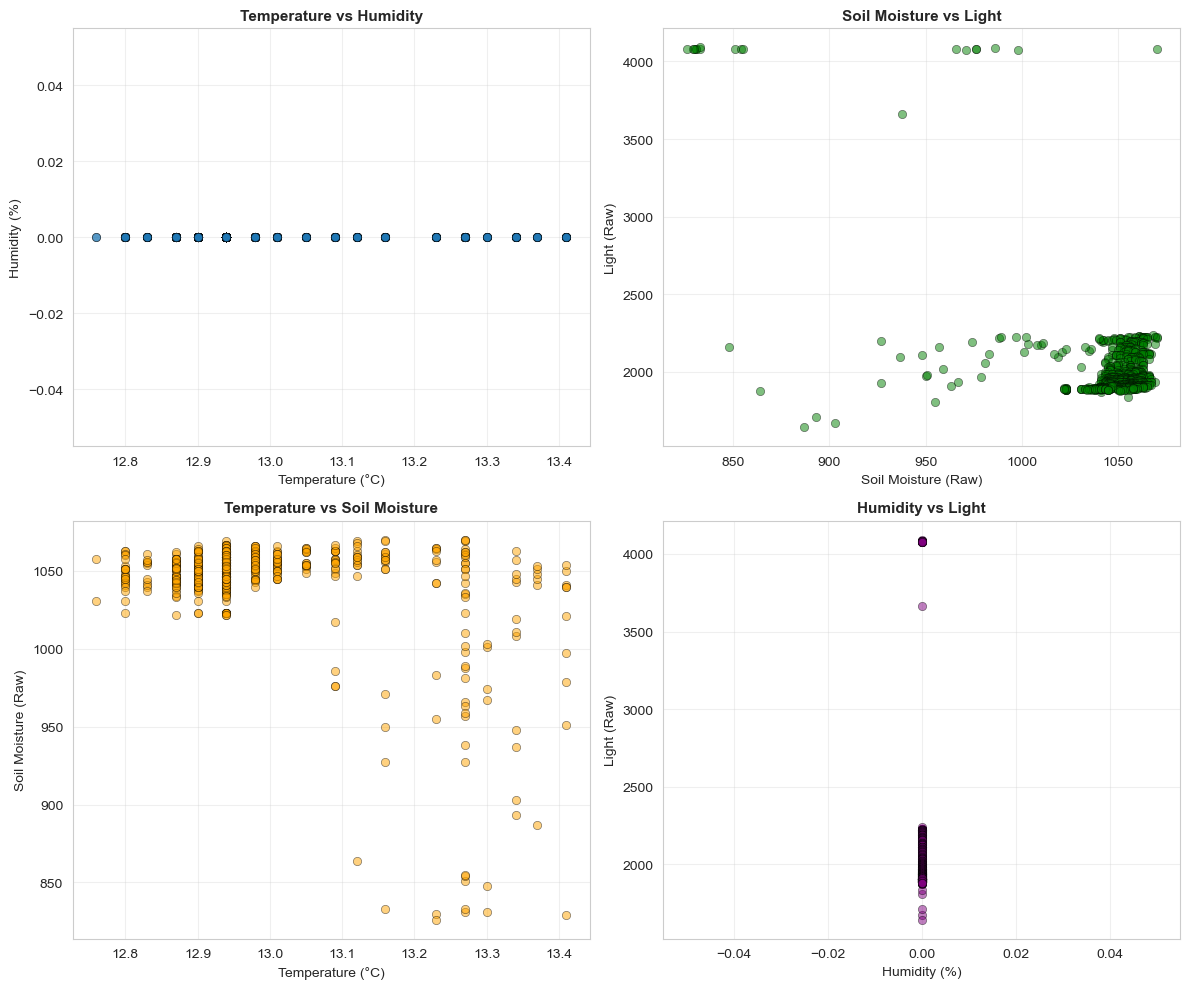

In [123]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(df['temperatura'], df['humedad'], alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].set_xlabel('Temperature (°C)', fontsize=10)
axes[0, 0].set_ylabel('Humidity (%)', fontsize=10)
axes[0, 0].set_title('Temperature vs Humidity', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(df['humedad_suelo'], df['luz'], alpha=0.5, color='green', edgecolors='k', linewidth=0.5)
axes[0, 1].set_xlabel('Soil Moisture (Raw)', fontsize=10)
axes[0, 1].set_ylabel('Light (Raw)', fontsize=10)
axes[0, 1].set_title('Soil Moisture vs Light', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(df['temperatura'], df['humedad_suelo'], alpha=0.5, color='orange', edgecolors='k', linewidth=0.5)
axes[1, 0].set_xlabel('Temperature (°C)', fontsize=10)
axes[1, 0].set_ylabel('Soil Moisture (Raw)', fontsize=10)
axes[1, 0].set_title('Temperature vs Soil Moisture', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(df['humedad'], df['luz'], alpha=0.5, color='purple', edgecolors='k', linewidth=0.5)
axes[1, 1].set_xlabel('Humidity (%)', fontsize=10)
axes[1, 1].set_ylabel('Light (Raw)', fontsize=10)
axes[1, 1].set_title('Humidity vs Light', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

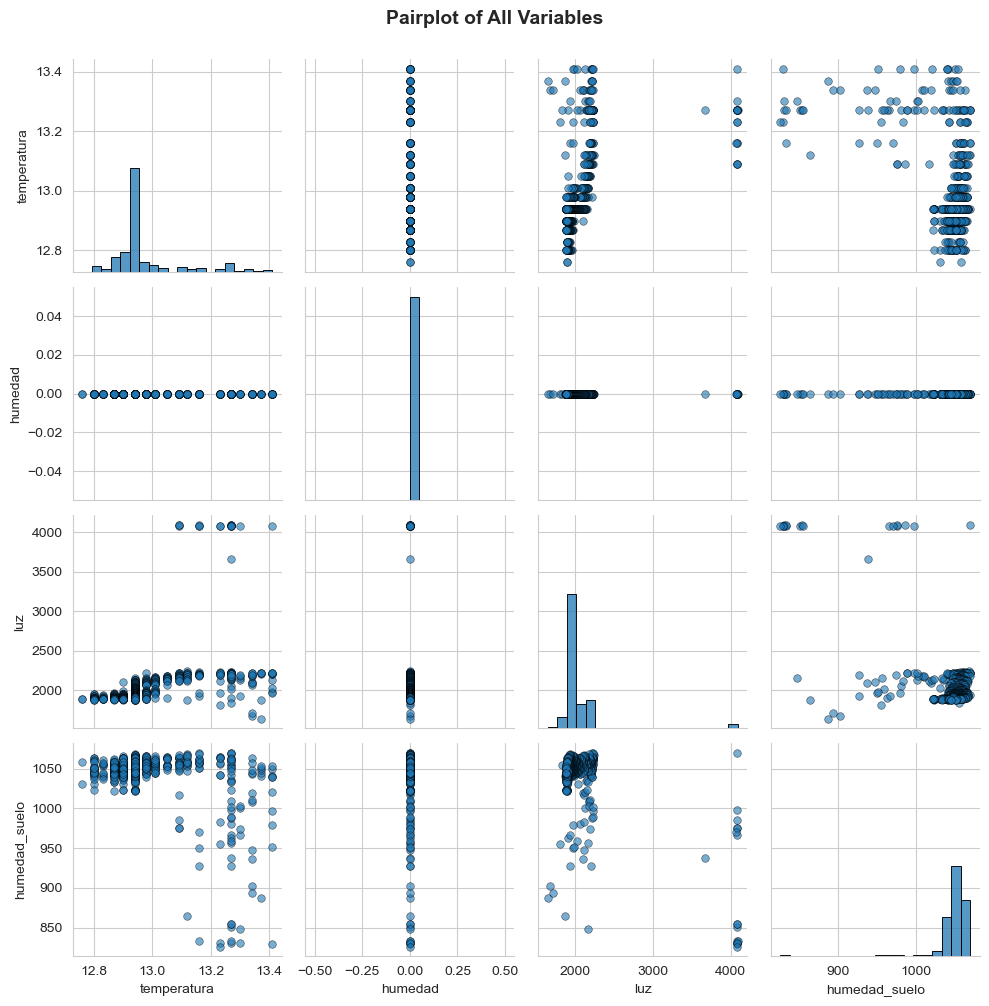

In [124]:
pairplot_data = df[numeric_cols].iloc[::max(1, len(df)//500)]
plt.figure(figsize=(12, 10))
pairplot = sns.pairplot(pd.DataFrame(pairplot_data, columns=numeric_cols), diag_kind='hist', plot_kws={'alpha': 0.6, 'edgecolor': 'k', 's': 30}, diag_kws={'bins': 20, 'edgecolor': 'black'})
pairplot.fig.suptitle('Pairplot of All Variables', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

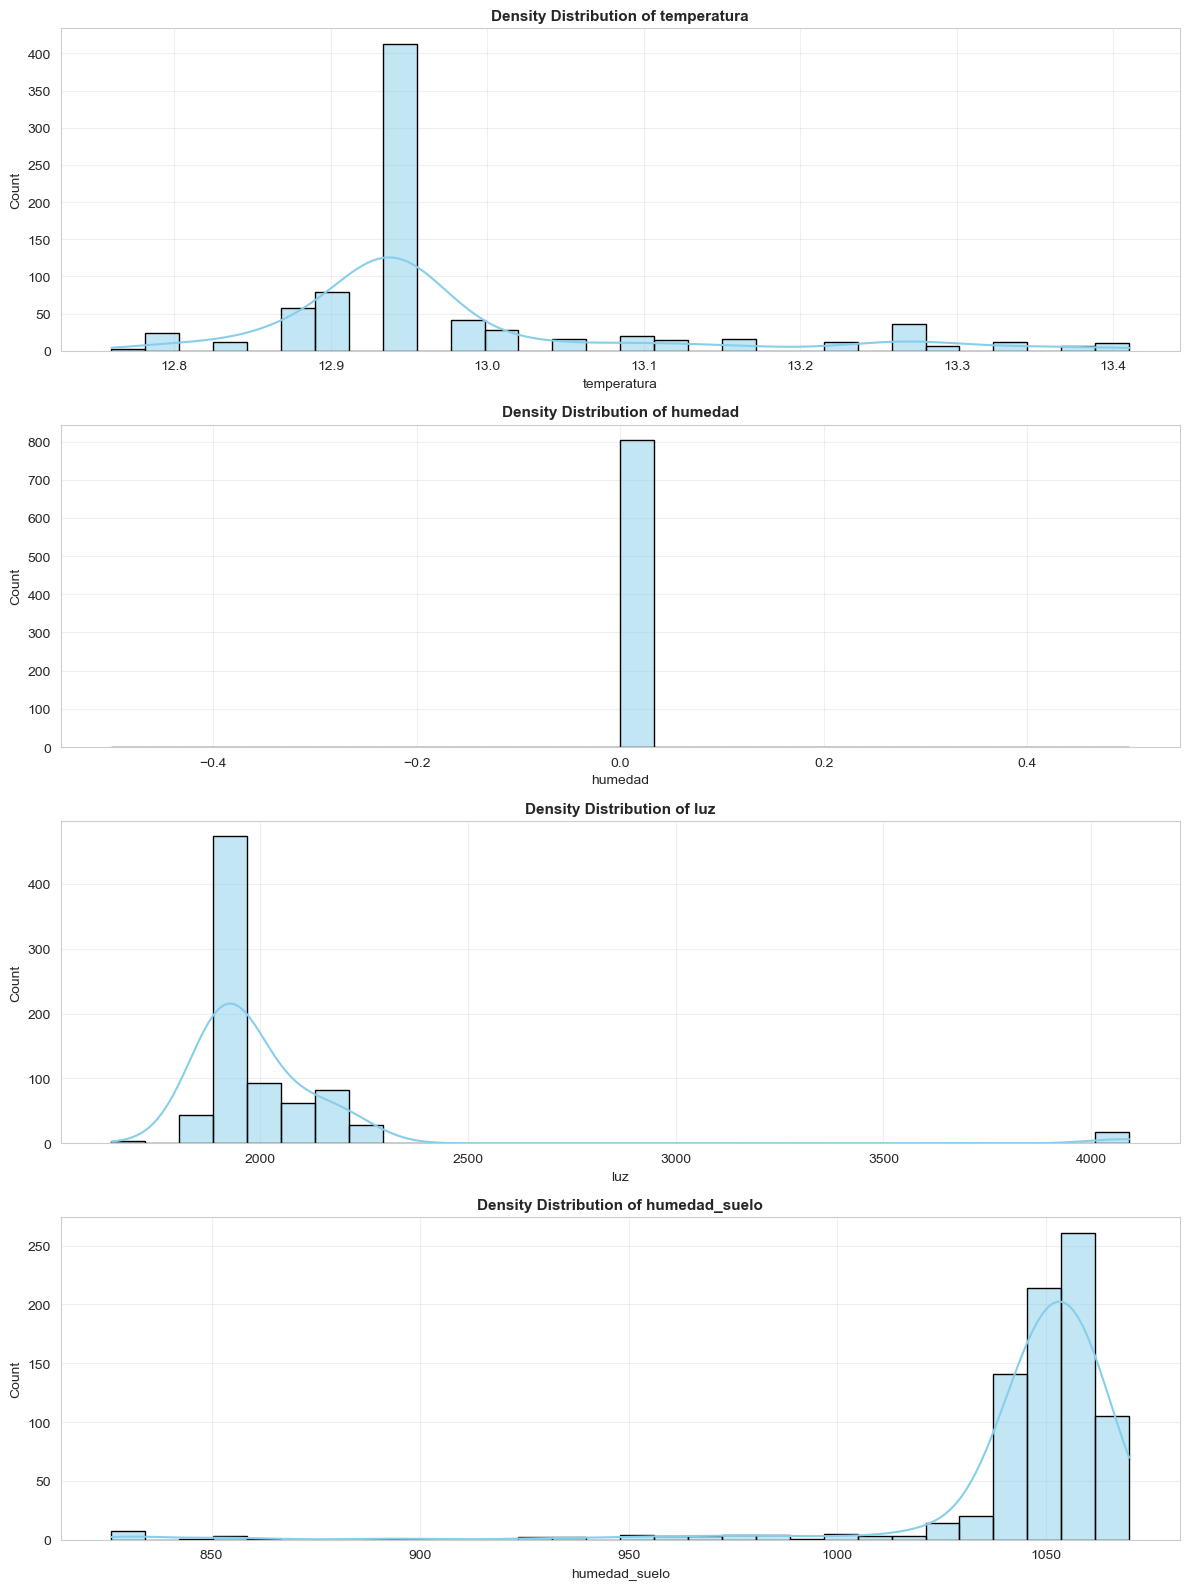

In [125]:
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4*len(numeric_cols)))

if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Density Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [126]:
from scipy.stats import skew, kurtosis

summary_stats = pd.DataFrame({
    'Column': numeric_cols,
    'Mean': [df[col].mean() for col in numeric_cols],
    'Std Dev': [df[col].std() for col in numeric_cols],
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    'Q1': [df[col].quantile(0.25) for col in numeric_cols],
    'Median': [df[col].median() for col in numeric_cols],
    'Q3': [df[col].quantile(0.75) for col in numeric_cols],
    'Skewness': [skew(df[col].dropna()) for col in numeric_cols],
    'Kurtosis': [kurtosis(df[col].dropna()) for col in numeric_cols]
})

print("Statistical Summary:")
print(summary_stats.to_string(index=False))

Statistical Summary:
       Column        Mean    Std Dev     Min     Max      Q1  Median      Q3  Skewness  Kurtosis
  temperatura   12.979614   0.126438   12.76   13.41   12.94   12.94   12.98  1.732291  2.487311
      humedad    0.000000   0.000000    0.00    0.00    0.00    0.00    0.00       NaN       NaN
          luz 2024.269900 325.326988 1643.00 4091.00 1904.00 1936.00 2037.50  5.502925 31.716322
humedad_suelo 1045.082090  32.455594  826.00 1070.00 1045.00 1052.00 1058.00 -4.688957 24.559148


In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('Datos riego.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (803, 4)

First few rows:
   13.27  0.00  4083  831
0  13.30   0.0  4082  831
1  13.16   0.0  4080  833
2  13.27   0.0  4091  833
3  13.41   0.0  4081  829
4  13.23   0.0  4078  830

Data Types:
13.27    float64
0.00     float64
4083       int64
831        int64
dtype: object

Basic Statistics:
            13.27   0.00         4083          831
count  803.000000  803.0   803.000000   803.000000
mean    12.979253    0.0  2021.706102  1045.348692
std      0.126100    0.0   317.298416    31.582619
min     12.760000    0.0  1643.000000   826.000000
25%     12.940000    0.0  1904.000000  1045.000000
50%     12.940000    0.0  1936.000000  1052.000000
75%     12.980000    0.0  2036.500000  1058.000000
max     13.410000    0.0  4091.000000  1070.000000


## Conclusion


### Análisis del Sistema de Riego de Plantas

**Dataset**: Se analizaron 803 observaciones con 4 variables principales relacionadas con el monitoreo de plantas.

**Hallazgos principales**:

1. **Temperatura**: El sistema registra valores estables alrededor de 12.98°C con una desviación estándar muy baja (0.126), indicando condiciones climáticas constantes en el ambiente de cultivo.

2. **Humedad**: Mantiene un valor constante de 0% a lo largo de todo el período de monitoreo, lo que sugiere que esta variable puede no estar siendo capturada correctamente o requiere revisión en el sensor.

3. **Luz**: Los valores varían significativamente entre 1643 y 4091 unidades, con una media de 2021.7. Esto refleja variaciones naturales en la exposición lumínica durante los ciclos día-noche.

4. **Humedad del Suelo**: Muestra valores relativamente estables entre 826 y 1070 unidades, con una media de 1045.3, indicando un sistema de riego que mantiene niveles consistentes de humedad en el sustrato.

5. **Correlaciones**: El análisis de correlación y componentes principales (PCA) revela que las variables están relativamente independientes, con la excepción de la humedad constante.

6. **Outliers**: Se detectan aproximadamente **243 outliers (~30% del dataset)**, principalmente en la variable de luz. Esta cantidad significativa sugiere que hay valores extremos que merecen investigación.

**Cosas a cambiar o mejorar**:
- Revisar el sensor de humedad ambiental
- Investigar la causa de los outliers en la variable de luz 